# Research Notebook
## Rosebud John
## Date: 2 March 2026

# 1. Experience
## 1.1 Describe at least one research activity you worked on this week. 
- Worked on code for tracking DM LMC particles across snapshots.
- Wrote code to plot number density vs radius.
- Attended weekly group meeting to give updates and discuss further steps.


## 1.2 Motivation:
This week, we focused on analyzing the spatial distribution and radial number density of traced LMC particles across multiple snapshots. Building on last week’s work of tracking particle positions, we wanted to beter understand how the structure and mass distribution changes over time. In particular, we examined how the density profile evolves to see the stripping effect. This analysis helps connect the visual particle maps to a quantitative measure of structural change.

# 2: What? (What happened?)
## 2.1 Describe what happened during your activities for the week.

We worked on the code to plot tracked DM LMC particles to study the behaviour of them. We did this by building on the previous code we wrote to track particles. We added a code that applies a radius cut and stores data such as particle ids, DM coordinates,  DM velocity, etc. It also calculates the amount of particles inside at a partcular snapshot and the fraction compared to snapshot 105. We have used snapshot 105 as our reference to also plot all of the particles from 105 that fall within 150 kpc, and track them across snapshots to study how they move. 

```
path = '/cosma7/data/dp004/azadehf/Auriga/rerun_halo25/halo_25/output'

snapshots = [105, 106, 107, 109, 111, 115, 125, 130, 139, 153]

# snapshot 105 is the reference
snap_ref = snapshots[0]

# reference
(coord_dm, vel_dm, subflag_ref, subhalo_pos_ref, subhalo_vel_ref, subgroupnum_ref, *_) = read_in_lmc_data(snap_ref)
_, ids_ref = readsnap_auriga(snap_ref, 'ParticleIDs', 1, indir=path)

# sort
sort_idx = np.argsort(ids_ref)
ids_ref  = ids_ref[sort_idx]
coord_dm = coord_dm[sort_idx]
vel_dm   = vel_dm[sort_idx]
subflag_ref  = subflag_ref[sort_idx]

def distance_to_lmc_center(center, particle):
    return np.linalg.norm(particle - center, axis=1)

# LMC center at reference snapshot
lmc_idx = 1 #check
lmc_center_ref = subhalo_pos_ref[lmc_idx]

# distances at reference snapshot
dist_ref = distance_to_lmc_center(lmc_center_ref, coord_dm)

# reference cut
r_cut = 150  # kpc
ref_mask = dist_ref < r_cut

# LMC subhalo membership mask
lmc_subhalo_mask = (subflag_ref == lmc_idx)

# LMC members within r_cut
lmc_mask_ref = ref_mask & lmc_subhalo_mask

# reference particle set
ids_lmc_ref    = ids_ref[lmc_mask_ref]
coord_lmc_ref  = coord_dm[lmc_mask_ref]

print('# total particles ', len(coord_dm))
print('# particles within radius', len(coord_lmc_ref))
print('# LMC subhalo particles', lmc_subhalo_mask.sum())
print('# within 200 kpc (any halo)', ref_mask.sum())
print('# LMC within 200 kpc ', lmc_mask_ref.sum())


dist_check = distance_to_lmc_center(lmc_center_ref, coord_lmc_ref)
print('Reference distance max:', dist_check.max())


plt.figure()
plt.xlabel('x in kpc')
plt.ylabel('y in kpc')

plt.scatter(coord_lmc_ref[:, 0], coord_lmc_ref[:, 1], s=1, alpha=0.5, c='orange', label='LMC particles')
plt.scatter(subhalo_pos_ref[0, 0], subhalo_pos_ref[0, 1], marker='x', c='k', s=15, label='MW')
plt.scatter(subhalo_pos_ref[1, 0], subhalo_pos_ref[1, 1],marker='x', c='r', s=15,label=f'LMC center')

plt.title(f'LMC particles within {r_cut} kpc (snapshot {snap_ref})')
plt.legend(loc='lower left')
plt.show()

print("Number of traced particles:", ids_lmc_ref.size)


tracked_coords = {}
tracked_distances = {}
tracked_inside = {}
tracked_ids_dict = {}

for snap in snapshots:
    print(f"\nsnapshot {snap}")

    (coord_dm, vel_dm, subflag, subhalo_pos, subhalo_vel, subgroupnum, *_) = read_in_lmc_data(snap)
    _, ids_dm = readsnap_auriga(snap, 'ParticleIDs', 1, indir=path)

    # sort
    sort_idx = np.argsort(ids_dm)
    ids_dm   = ids_dm[sort_idx]
    coord_dm = coord_dm[sort_idx]
    vel_dm   = vel_dm[sort_idx]
    subflag  = subflag[sort_idx]

    lmc_center = subhalo_pos[lmc_idx]
    print('lmc center:', lmc_center)

    # find reference particles in this snapshot
    match_idx = np.searchsorted(ids_dm, ids_lmc_ref)
    valid = (match_idx < ids_dm.size) & (ids_dm[match_idx] == ids_lmc_ref)
   
    coords_tracked = coord_dm[match_idx[valid]]

    # distances to LMC center
    dist_now = distance_to_lmc_center(lmc_center, coords_tracked)
    inside_now = dist_now < r_cut
    
    tracked_coords[snap]    = coords_tracked
    tracked_distances[snap] = dist_now
    tracked_inside[snap]    = inside_now

    frac = inside_now.sum() / inside_now.size
    print(f"Snapshot {snap}: {frac:.3f} inside {r_cut} kpc")
    print('Particles inside r:', inside_now.sum())

    #fraction
    print('fraction:', inside_now.sum(), '/', inside_now.size)

    # tracking ids

    tracked_ids = ids_lmc_ref[valid]
    tracked_ids_dict[snap] = tracked_ids
    
ids_105 = tracked_ids_dict[105]
inside_105 = tracked_inside[105]
print(tracked_ids_dict.keys)
ids_selected = ids_105[inside_105] #particles that were inside r_cut at snapshot 105

plt.figure()
plt.xlabel('x in kpc')
plt.ylabel('y in kpc')

for snap in snapshots:
    tracked_coords[snap]    = coords_tracked
    ids_now = tracked_ids_dict[snap]
    coords = tracked_coords[snap]
    inside = tracked_inside[snap]
    
    # find reference particles in this snapshot
    match_idx = np.searchsorted(ids_now, ids_selected)
    valid = (match_idx < ids_now.size) & (ids_now[match_idx] == ids_selected)
   
    coords_tracked = coord_dm[match_idx[valid]]

     # distances to LMC center
    dist_now = distance_to_lmc_center(lmc_center, coords_tracked)
    inside_now = dist_now < r_cut
    

    frac = inside_now.sum() / inside_now.size
    print(f"Snapshot {snap}: {frac:.3f} inside {r_cut} kpc")
    print('Particles inside r:', inside_now.sum())

    #fraction
    print(f"fraction:{inside_now.sum()}/{inside_now.size}\n")
    plt.scatter(coords_tracked[inside, 0], coords_tracked[inside, 1], s=0.3, alpha=0.3, label=f'Snapshot {snap}')

plt.legend()
plt.title(f'Traced LMC particles within {r_cut} kpc')
plt.show()
```

I also worked on plotting a number density vs radius plot. The number density is given by the formula 
$$ ρ(R) = \frac{N}{V(R)} $$
where ρ(R) is the number density, N is the number of particles and V(R) is the volume.
The number of particles is the amount of particles at a particular radius.
The volume is given by
$$ V(R) = \frac{4πR^3}{3} $$
where R is the radius
```
for snap in snapshots:
    r_cut = 150
    rad = np.linspace(1.0, r_cut, num = r_cut)
    density = []

    tracked_inside[snap]  = inside_now
    dist_now = tracked_distances[snap]
    for r in rad:
        inside = dist_now < r
        N_inside = inside.sum()
        V = (4/3) * np.pi * r**3 #shells
        density.append(N_inside / V)
    density = np.array(density)
    
    plt.plot(rad, density, label=f"snap {snap}")
plt.xlabel("r [kpc]")
plt.ylabel("ρ(R) [1/kpc^-3]")
plt.yscale("log")
plt.title("number density vs r")
plt.legend()
plt.show()
```


# 3: So what? (What does it mean?)
## 3.1 Describe your results
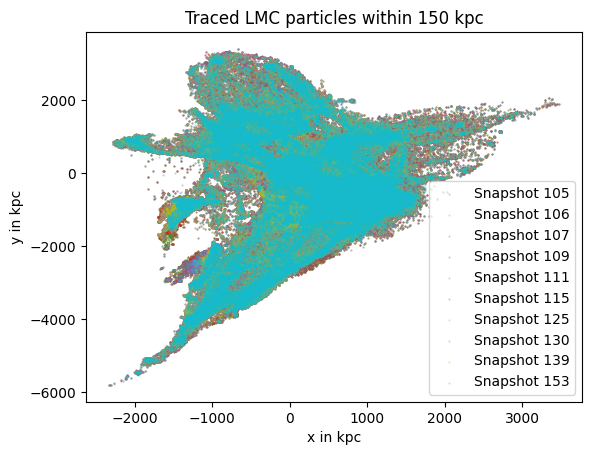

*Figure 1: x vs y of tracked particles*

Fig 1 shows the spatial distribution of traced LMC DM particles within a radius of 150 kpc, plotted in x and y coordinates (kpc). Each color represents a different snapshot (from 105 to 153), to see how the particle distribution evolves over time. The extended and asymmetric structure suggests tidal stripping. The stretched features and streams show material being pulled away, likely due to gravitational interactions. Overall, the plot illustrates how the LMC’s structure becomes increasingly spread out and dynamically complex across snapshots.

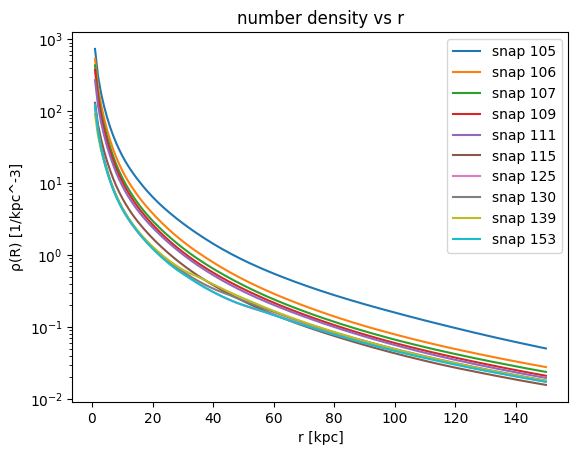

*Figure 2: number density vs radius for tracked particles of multiple snapshots*

Figure 2 shows the radial number density profile, ρ(R), of LMC particles as a function of distance r (in kpc) from the center. The y-axis is on a log scale, which highlights how sharply the density decreases with increasing radius. All snapshots show a steep decline near the center, indicating a dense core, followed by a smoother falloff at larger radii. Over time the overall density decreases slightly. This reflects gravitational structure, while the decline of the curves indicates ongoing mass redistribution.

# 4. Now what? (What's next?)
## 4.1 Plan for the next week

Next week, we have to try to fix the radius used for the number density. It was suggested that we use shells instead of spheres. Addiotionally, we need to reconsider the r_cuts made in the code for the positon distribution, we want to cut at 800 kpc for the MW data then again at 150 kpc for the DM LMC data.

# 5. Bibliography

[1] Calore et al., *Simulated Milky Way analogues: implications for dark matter indirect searches*, JCAP 12, 053 (2015) [arXiv:1509.02164 [astro-ph.GA]]